In [103]:
import numpy as np 
import pandas as pd 
import seaborn as sns; sns.set_style('whitegrid')
import matplotlib.pyplot as plt 

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv


In [104]:
df = pd.read_csv(r'/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [105]:
print(f"DataFrame's shape: {df.shape}")
print(f"DataFrame columns: {df.columns}")

DataFrame's shape: (7043, 21)
DataFrame columns: Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')


In [106]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [107]:
df.describe(include=['int64', 'float64'])

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [116]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,PaymentMethod,Churn,gmm_cluster
0,0,0,1,0,1,0,1,0,0,2,...,0,0,0,0,1,29.85,29.85,2,0,1
1,1,0,0,0,34,1,0,0,2,0,...,0,0,0,1,0,56.95,1889.50,3,0,1
2,1,0,0,0,2,1,0,0,2,2,...,0,0,0,0,1,53.85,108.15,3,1,1
3,1,0,0,0,45,0,1,0,2,0,...,2,0,0,1,0,42.30,1840.75,0,0,1
4,0,0,0,0,2,1,0,1,0,0,...,0,0,0,0,1,70.70,151.65,2,1,0


### 1. Demographics (Customer Profile)

CustomerID(HashValue) - unique identifier of the customer;

Gender(Binary[Male/Female]) - gender of the customer;

SeniorCitizen(Boolean) - whether the customer is a pensioner or not (1: Yes, 0: No);

Partner(Binary[Yes/No]) - whether the customer has a partner or not;

Dependents(Binary[Yes/No]) - whether the customer has dependents or not (children, elderly parents, etc.);

### 2. Services (Usage Details)

Tenure(Integer) - number of months the customer has stayed with the company;

PhoneService(Binary[Yes/No]) - whether the customer has a phone service or not;

MultipleLines(Categorical[Yes/No/No phone service]) - whether the customer has multiple lines or not;

InternetService(Categorical[DSL/Fiber optic/No]) - customer’s internet service provider;

OnlineSecurity(Categorical[Yes/No/No internet service]) - whether the customer has online security or not;

OnlineBackup(Categorical[Yes/No/No internet service]) - whether the customer has online backup or not;

DeviceProtection(Categorical[Yes/No/No internet service]) - whether the customer has device protection or not;

TechSupport(Categorical[Yes/No/No internet service]) - whether the customer has tech support or not;

StreamingTV(Categorical[Yes/No/No internet service]) - whether the customer has streaming TV or not;

StreamingMovies(Categorical[Yes/No/No internet service]) - whether the customer has streaming movies or not;

### 3. Billing & Contract (Financials)

Contract(Categorical[Month-to-month/One year/Two year]) - the contract term of the customer;

PaperlessBilling(Binary[Yes/No]) - whether the customer has paperless billing or not;

PaymentMethod(Categorical) - the customer’s payment method (Electronic check, Mailed check, Bank transfer (automatic), Credit card (automatic));

MonthlyCharges(Float) - the amount charged to the customer monthly;

TotalCharges(Float) - the total amount charged to the customer;

### 4. Target Variable

Churn(Binary[Yes/No]) - whether the customer churned (left the company) or not.

In [117]:
df.dtypes

gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines         int64
InternetService       int64
OnlineSecurity        int64
OnlineBackup          int64
DeviceProtection      int64
TechSupport           int64
StreamingTV           int64
StreamingMovies       int64
Contract              int64
PaperlessBilling      int64
MonthlyCharges      float64
TotalCharges        float64
PaymentMethod         int64
Churn                 int64
gmm_cluster           int64
dtype: object

In [109]:
from sklearn.preprocessing import LabelEncoder

binary_object_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
      'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'Churn']
le = LabelEncoder()

for col in binary_object_cols:
    df[col] = le.fit_transform(df[col])
    
    mapping = dict(zip(le.classes_, range(len(le.classes_))))
    
    print(f"Столбец [{col}]: {mapping}")

Столбец [gender]: {'Female': 0, 'Male': 1}
Столбец [SeniorCitizen]: {np.int64(0): 0, np.int64(1): 1}
Столбец [Partner]: {'No': 0, 'Yes': 1}
Столбец [Dependents]: {'No': 0, 'Yes': 1}
Столбец [PhoneService]: {'No': 0, 'Yes': 1}
Столбец [MultipleLines]: {'No': 0, 'No phone service': 1, 'Yes': 2}
Столбец [InternetService]: {'DSL': 0, 'Fiber optic': 1, 'No': 2}
Столбец [OnlineSecurity]: {'No': 0, 'No internet service': 1, 'Yes': 2}
Столбец [OnlineBackup]: {'No': 0, 'No internet service': 1, 'Yes': 2}
Столбец [DeviceProtection]: {'No': 0, 'No internet service': 1, 'Yes': 2}
Столбец [TechSupport]: {'No': 0, 'No internet service': 1, 'Yes': 2}
Столбец [StreamingTV]: {'No': 0, 'No internet service': 1, 'Yes': 2}
Столбец [StreamingMovies]: {'No': 0, 'No internet service': 1, 'Yes': 2}
Столбец [Contract]: {'Month-to-month': 0, 'One year': 1, 'Two year': 2}
Столбец [PaperlessBilling]: {'No': 0, 'Yes': 1}
Столбец [PaymentMethod]: {'Bank transfer (automatic)': 0, 'Credit card (automatic)': 1, 'Elect

## Segmentation 

### k-means


In [110]:
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 
        'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 
        'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 
        'StreamingMovies', 'Contract', 'PaperlessBilling', 'MonthlyCharges', 
        'TotalCharges', 'PaymentMethod', 'Churn']

df_clean = df[cols].copy()
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')
df_clean['MonthlyCharges'] = pd.to_numeric(df_clean['MonthlyCharges'], errors='coerce')


df = df_clean.dropna()

df = df.reset_index(drop=True)

<Axes: >

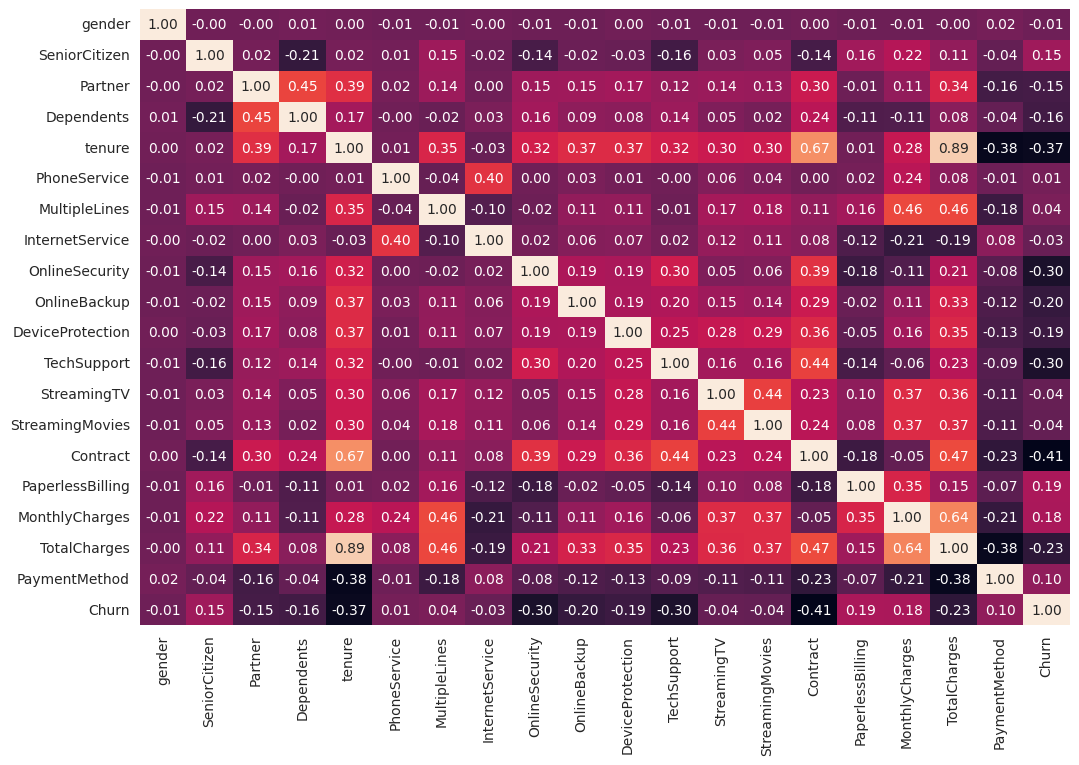

In [111]:
plt.figure(figsize=(12, 8))
sns.heatmap(
   df.corr(method='spearman'),
    annot=True,
    fmt='.2f',
    cbar=False
)   

In [112]:
# inertia = []
# K = range(1, 11)

# for k in K:
#     kmeanModel = KMeans(n_clusters=k, n_init='auto', random_state=42)
#     kmeanModel.fit(df)
#     inertia.append(kmeanModel.inertia_)

# plt.plot(K, inertia, 'bx-')
# plt.xlabel('Number of Clusters (k)')
# plt.ylabel('Inertia')
# plt.title('The Elbow Method showing the optimal k')
# plt.show()

In [113]:
# kmeans = KMeans(n_clusters=3, n_init='auto')
# labels = kmeans.fit_predict(df)

# score = silhouette_score(df, labels)
# print(f"Average silhoutte score: {score:.3f}")

### Gaussian-mixture-models

In [118]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=3, random_state=42)

gmm_labels = gmm.fit_predict(df)

probs = gmm.predict_proba(df)

df['gmm_cluster'] = gmm_labels

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,PaymentMethod,Churn,gmm_cluster
0,0,0,1,0,1,0,1,0,0,2,...,0,0,0,0,1,29.85,29.85,2,0,1
1,1,0,0,0,34,1,0,0,2,0,...,0,0,0,1,0,56.95,1889.50,3,0,1
2,1,0,0,0,2,1,0,0,2,2,...,0,0,0,0,1,53.85,108.15,3,1,1
3,1,0,0,0,45,0,1,0,2,0,...,2,0,0,1,0,42.30,1840.75,0,0,1
4,0,0,0,0,2,1,0,1,0,0,...,0,0,0,0,1,70.70,151.65,2,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,1,0,1,1,24,1,2,0,2,0,...,2,2,2,1,1,84.80,1990.50,3,0,0
7028,0,0,1,1,72,1,2,1,0,2,...,0,2,2,1,1,103.20,7362.90,1,0,0
7029,0,0,1,1,11,0,1,0,2,0,...,0,0,0,0,1,29.60,346.45,2,0,1
7030,1,1,1,0,4,1,2,1,0,0,...,0,0,0,0,1,74.40,306.60,3,1,2


In [134]:
## Does not worl since the min pca used to explain the data is 8...
# from sklearn.decomposition import PCA
# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()
# features_scaled = scaler.fit_transform(df.drop(['gmm_cluster', 'Churn'], axis=1))

# pca = PCA(n_components=10)
# components = pca.fit_transform(features_scaled)


# # plt.figure(figsize=(10, 7))
# # sns.scatterplot(x=components[:, 0], y=components[:, 1], hue=df['gmm_cluster'], palette='viridis', alpha=0.5)
# # plt.title('Разделение кластеров в пространстве PCA')
# # plt.show()

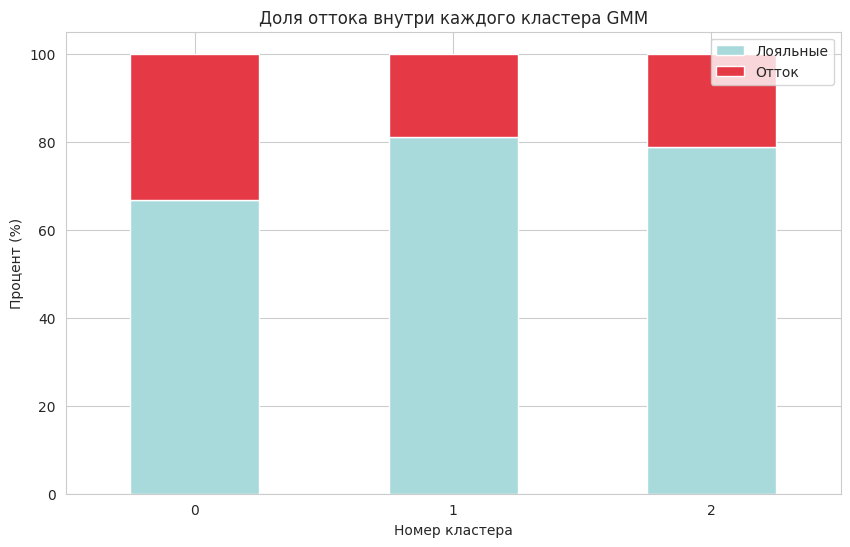

In [139]:
# Description of clusters
churn_by_cluster = pd.crosstab(df['gmm_cluster'], df['Churn'], normalize='index') * 100

churn_by_cluster.plot(kind='bar', stacked=True, color=['#A8DADC', '#E63946'], figsize=(10, 6))
plt.title('Доля оттока внутри каждого кластера GMM')
plt.ylabel('Процент (%)')
plt.xlabel('Номер кластера')
plt.legend(['Лояльные', 'Отток'], loc='upper right')
plt.xticks(rotation=0)
plt.show()

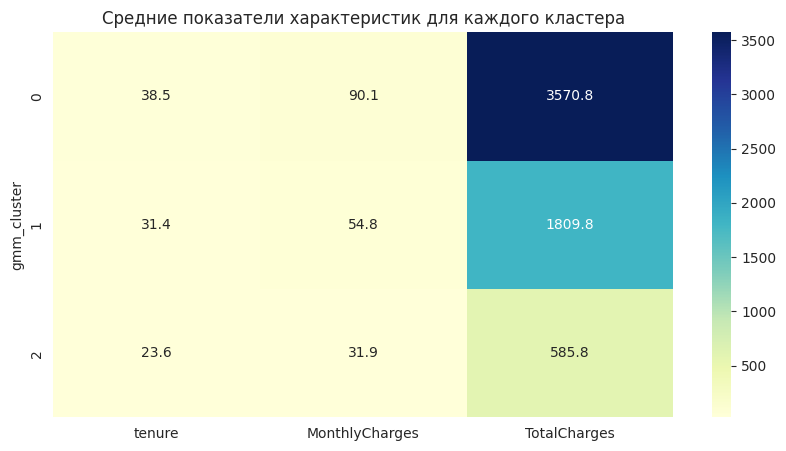

In [140]:
# Profiling the Clusters 
features_to_compare = ['tenure', 'MonthlyCharges', 'TotalCharges']
cluster_profiles = df.groupby('gmm_cluster')[features_to_compare].mean()


plt.figure(figsize=(10, 5))
sns.heatmap(cluster_profiles, annot=True, cmap='YlGnBu', fmt='.1f')
plt.title('Средние показатели характеристик для каждого кластера')
plt.show()

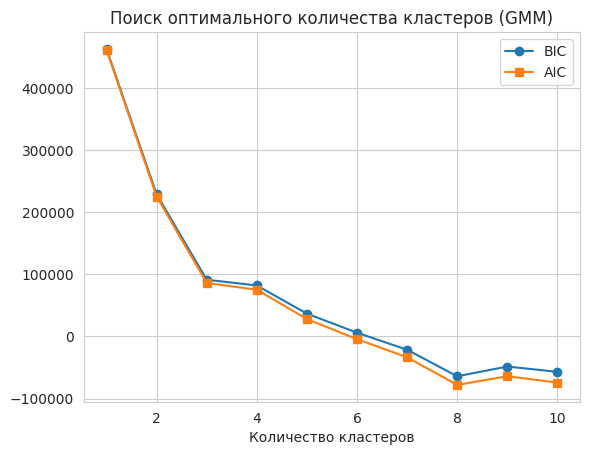

In [141]:
n_components = range(1, 11)
models = [GaussianMixture(n, covariance_type='full', random_state=42).fit(df) for n in n_components]

plt.plot(n_components, [m.bic(df) for m in models], label='BIC', marker='o')
plt.plot(n_components, [m.aic(df) for m in models], label='AIC', marker='s')
plt.xlabel('Количество кластеров')
plt.legend()
plt.title('Поиск оптимального количества кластеров (GMM)')
plt.show()

### hdscan

In [ ]:
# cluster_profile = df.groupby('Cluster_Labels').mean(numeric_only=True)

# cluster_profile['count'] = df.groupby('Cluster_Labels').size()

# plt.figure(figsize=(18, 20))
# sns.heatmap(
#     cluster_profile,
#     annot=True, 
#     fmt='.2f',
#     cbar=False,
#     linecolor='white',
#     linewidth=2
# )